# Assets Pricing Prediction with XGBoost

In [1]:
import sys

print(sys.executable)

!{sys.executable} -m pip uninstall plotly -y
!{sys.executable} -m pip install --no-cache-dir --force-reinstall plotly

C:\Users\pabda\anaconda3\envs\quant-pdr\python.exe


   ---------------------------------------- 0.0/9.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.1 MB ? eta -:--:--
   ------ --------------------------------- 1.6/9.1 MB 7.6 MB/s eta 0:00:01
   ------------------------------------- -- 8.4/9.1 MB 21.7 MB/s eta 0:00:01
   ---------------------------------------- 9.1/9.1 MB 20.1 MB/s  0:00:00

  Attempting uninstall: packaging

    Found existing installation: packaging 26.0

    Uninstalling packaging-26.0:

      Successfully uninstalled packaging-26.0

   ---------------------------------------- 0/3 [packaging]
   ---------------------------------------- 0/3 [packaging]
   ---------------------------------------- 0/3 [packaging]
   ---------------------------------------- 0/3 [packaging]
  Attempting uninstall: narwhals
   ---------------------------------------- 0/3 [packaging]
    Found existing installation: narwhals 2.25.0
   ---------------------------------------- 0/3 [packaging]
   ------------- ----------

Install the libs if doesn't exists

In [2]:
!pip install plotly

In [1]:
# Import libs
import time
import numpy as np
import pandas as pd
import yfinance as yf
import xgboost as xgb

from xgboost import plot_importance
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import GridSearchCV

import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [2]:
import sys
print(sys.executable)

C:\Users\pabda\anaconda3\envs\quant-pdr\python.exe


In [3]:
# Load data
df = yf.download("SPY", start = "2010-01-01", end = "2024-01-01", interval="1d")
df

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,SPY,SPY,SPY,SPY,SPY
Date,,,,,
2010-01-04,84.578491,84.623268,83.220220,83.862041,118944600
2010-01-05,84.802361,84.839678,84.220245,84.526232,111579900
2010-01-06,84.862091,85.071055,84.653127,84.720292,116074400
2010-01-07,85.220329,85.324811,84.466562,84.705378,131091100
2010-01-08,85.503899,85.541216,84.824766,84.996413,126402800
...,...,...,...,...,...
2023-12-22,459.779907,461.459258,457.887028,459.983749,67160400
2023-12-26,461.721313,462.624073,460.109920,460.187594,55387000


In [4]:
# Plotting data
import plotly.io as pio

# Force Plotly to open the graph in the web browser
pio.renderers.default = "browser"

open = df["Open"]
close = df["Close"]
high = df["High"]
low = df["Low"]
volume = df["Volume"]

open_val = open.squeeze()
close_val = close.squeeze()
high_val = high.squeeze()
low_val = low.squeeze()
volume_val = volume.squeeze()

fig = make_subplots(
    rows=2,
    cols=1,
    shared_xaxes=True,
    vertical_spacing=0.03,
    row_heights=[0.8, 0.2]
)

# Candlestick chart
fig.add_trace(
    go.Candlestick(
        x=df.index,
        open=open_val,
        high=high_val,
        low=low_val,
        close=close_val,
        name="S&P 500"
    ),
    row=1,
    col=1
)

# Volume
fig.add_trace(
    go.Bar(
        x=df.index,
        y=volume_val,
        name="Volume"
    ),
    row=2,
    col=1
)

fig.update_layout(
    height=700,
    width=1200,
    title="S&P 500 - Candlestick and Volume",
    xaxis_rangeslider_visible=False
)

fig.show()

## Adding Tencnical Indicators

### Mobiles Averages


In [5]:
# Adding different mobile averages
windows = [9, 10, 14, 20, 21, 50]
for i in windows:
    df[f"MA_{i}"] = close.rolling(i, min_periods=i).mean()

#New variables with data
df

Price,Close,High,Low,Open,Volume,MA_9,MA_10,MA_14,MA_20,MA_21,MA_50
Ticker,SPY,SPY,SPY,SPY,SPY,,,,,,
Date,,,,,,,,,,,
2010-01-04,84.578491,84.623268,83.220220,83.862041,118944600,NaN,NaN,NaN,NaN,NaN,NaN
2010-01-05,84.802361,84.839678,84.220245,84.526232,111579900,NaN,NaN,NaN,NaN,NaN,NaN
2010-01-06,84.862091,85.071055,84.653127,84.720292,116074400,NaN,NaN,NaN,NaN,NaN,NaN
2010-01-07,85.220329,85.324811,84.466562,84.705378,131091100,NaN,NaN,NaN,NaN,NaN,NaN
2010-01-08,85.503899,85.541216,84.824766,84.996413,126402800,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
2023-12-22,459.779907,461.459258,457.887028,459.983749,67160400,456.418003,455.441248,451.674837,448.440350,448.047124,431.322427
2023-12-26,461.721313,462.624073,460.109920,460.187594,55387000,457.865882,456.948334,453.123542,449.556921,449.072777,432.213397


In [6]:
# Plotting mobile averages
fig = go.Figure()
for i in windows:
    fig.add_trace(go.Scatter(x=df.index, y=df[f"MA_{i}"], name=f"Mobile Average {i}"))

#Adding close price
fig.add_trace(go.Scatter(x=df.index, y=close, name="Close", opacity=0.5))
fig.update_layout(title="Different Mobile Averages")
fig.show()

# RSI

In [7]:
#Implementation
def Relative_Strength_Index(df: pd.DataFrame, length: int = 14) -> pd.Series:
    """
    The Relative Strength Index (RSI) it's commonly used into the technical analysis to measure \n
    the magnitude of the resently prices changes to evaluete the overbought or oversold conditions \n
    in the asset price or another financial active.
    """

    #Calculate
    Delta = close_val.diff(periods=1)
    Gain = Delta.where(Delta >= 0, 0)
    Loss = np.abs(Delta.where(Delta < 0, 0))
    avg_gain = Gain.ewm(alpha=1/length, min_periods=length).mean() #Exponential moving average
    avg_loss = Loss.ewm(alpha=1/length, min_periods=length).mean() #Exponential moving average
    RS = avg_gain / avg_loss
    RSI = pd.Series(np.where(RS == 0, 100, 100 - (100/(1+RS))), name="RSI", index=df.index)

    return RSI

In [8]:
# Add inticator to our data
windows = [9,10,14,20,21,50]
for i in windows:
    df[f"RSI_{i}"] = Relative_Strength_Index(df, length=i)

fig = make_subplots(rows=3, cols=2)
fig.add_trace(go.Scatter(x=df.index, y=df["RSI_9"], name="RSI 9"), row=1, col=1)
fig.add_trace(go.Scatter(x=df.index, y=df["RSI_10"], name="RSI 10"), row=1, col=2)
fig.add_trace(go.Scatter(x=df.index, y=df["RSI_14"], name="RSI 14"), row=2, col=1)
fig.add_trace(go.Scatter(x=df.index, y=df["RSI_20"], name="RSI 20"), row=2, col=2)
fig.add_trace(go.Scatter(x=df.index, y=df["RSI_21"], name="RSI 21"), row=3, col=1)
fig.add_trace(go.Scatter(x=df.index, y=df["RSI_50"], name="RSI 50"), row=3, col=2)


fig.update_layout(title="RSI Analysis to differetn timerates")
fig.show()

### MACD Indicator

In [9]:
#Calculates indicator
df["EMA_12"] = pd.Series(close_val.ewm(span=12, min_periods=12).mean())
df["EMA_26"] = pd.Series(close_val.ewm(span=26, min_periods=26).mean())
df["MACD"] = df["EMA_12"] - df["EMA_26"]
df["MACD_signal"] = df["MACD"].ewm(span=9, min_periods=9).mean()

# Plotting
fig = make_subplots(rows=2, cols=1)
fig.add_trace(go.Scatter(x=df.index, y=close_val, name="Close"), row=1, col=1)
fig.add_trace(go.Scatter(x=df.index, y=df["EMA_12"], name="EMA 12"), row=1, col=1)
fig.add_trace(go.Scatter(x=df.index, y=df["EMA_26"], name="EMA 26"), row=1, col=1)
fig.add_trace(go.Scatter(x=df.index, y=df["MACD"], name="MACD"), row=2, col=1)
fig.add_trace(go.Scatter(x=df.index, y=df["MACD_signal"], name="MACD signal"), row=2, col=1)
fig.show()


## Clean and Fit data

In [10]:
# Displacing 1 pocition all data to predict with a day ago data (without close, because it's de data to predict)
Close = df["Close"]
df = df.shift(periods=1)
df["Close"] = Close
# Deleting NANs values
df.dropna(inplace=True)
df

Price,Close,High,Low,Open,Volume,MA_9,MA_10,MA_14,MA_20,MA_21,...,RSI_9,RSI_10,RSI_14,RSI_20,RSI_21,RSI_50,EMA_12,EMA_26,MACD,MACD_signal
Ticker,SPY,SPY,SPY,SPY,SPY,,,,,,...,,,,,,,,,,
Date,,,,,,,,,,,,,,,,,,,,,
2010-03-17,87.392044,86.959209,86.190518,86.429335,168673000.0,85.692130,85.503898,84.822628,84.156823,84.049320,...,85.595096,83.015883,75.054680,68.287656,67.526161,59.109145,85.267085,84.161100,1.105985,0.816996
2010-03-18,87.347267,87.675643,86.884558,87.138304,177468100.0,86.061964,85.862122,85.165394,84.412058,84.310881,...,87.708774,85.206558,77.195189,70.133233,69.327842,60.327487,85.594067,84.405249,1.188818,0.891586
2010-03-19,86.905151,87.518914,86.996504,87.399508,196509100.0,86.293320,86.190495,85.501231,84.640799,84.551830,...,86.467562,84.157744,76.579816,69.761605,68.978413,60.168414,85.863836,84.627234,1.236602,0.960756
2010-03-22,87.369705,87.894328,86.567929,86.905151,226641100.0,86.473891,86.354503,85.744185,84.838853,84.748626,...,74.721722,74.145131,70.595784,66.120136,65.552987,58.611304,86.024061,84.798874,1.225187,1.013745
2010-03-23,87.984245,87.527079,86.358049,86.410505,184477800.0,86.690325,86.563472,86.003796,85.059388,84.959370,...,78.219216,77.298440,72.984565,67.969411,67.342261,59.728733,86.231108,84.992338,1.238771,1.058820
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-22,459.779907,459.129527,455.110746,457.527820,86667500.0,454.959174,453.955249,450.371020,447.460484,447.101028,...,69.897009,70.322940,70.642717,69.091147,68.755118,61.739188,452.702915,445.039663,7.663252,7.218448
2023-12-26,461.721313,461.459258,457.887028,459.983749,67160400.0,456.418003,455.441248,451.674837,448.440350,448.047124,...,71.062437,71.371199,71.405126,69.657490,69.300304,62.015892,453.791683,446.131533,7.660150,7.306789


## Spliting data into train, validation and test
train -  used to train the model to know patterns on basis of the data, must to represent the diversity of the general data to learn objectively and effectively, and generalize well in new observations
validation - used to adjust the model's hyperparams, and evaluates the returns during the training, that's commonly used to test the train validations to adjust the testing values
test - evaluates the final return, to adjust the data

In [11]:
test_size = 0.10
validation_size = 0.1
train_size = 0.8

#Division indexes to the dataset
test_index_division = int(df.shape[0] * (1 - test_size))
validation_index_division = int(df.shape[0] * (1 - (validation_size + test_size)))

# Training, validation and test datasets
train_dataset = df.iloc[:validation_index_division].copy()
validation_dataset = df.iloc[validation_index_division+1:test_index_division].copy()
test_dataset = df.iloc[test_index_division+1:].copy()

#Plotting data
fig = go.Figure()
fig.add_trace(go.Scatter(x=train_dataset.index, y=train_dataset["Close"].squeeze(), name="Training"))
fig.add_trace(go.Scatter(x=validation_dataset.index, y=validation_dataset["Close"].squeeze(), name="Validation"))
fig.add_trace(go.Scatter(x=test_dataset.index, y=test_dataset["Close"].squeeze(), name="Test"))
fig.update_layout(title="Data divition")
fig.show()

## Deleting Columns

In [12]:
# Defining all columns that we don't want to use
#deleting_columns = ["Adj Close", "Open", "High", "Low", "Volume"] #in this project doesn't have adj close
deleting_columns = ["Open", "High", "Low", "Volume"]

train_dataset = train_dataset.drop(columns=deleting_columns)
validation_dataset = validation_dataset.drop(columns=deleting_columns)
test_dataset = test_dataset.drop(columns=deleting_columns)

In [13]:
train_dataset
validation_dataset
test_dataset

Price,Close,MA_9,MA_10,MA_14,MA_20,MA_21,MA_50,RSI_9,RSI_10,RSI_14,RSI_20,RSI_21,RSI_50,EMA_12,EMA_26,MACD,MACD_signal
Ticker,SPY,,,,,,,,,,,,,,,,
Date,,,,,,,,,,,,,,,,,
2022-08-15,406.524658,394.078508,393.608340,390.158868,384.891747,383.947954,373.404719,79.122175,77.576672,72.134077,65.975515,65.156727,54.354120,391.979214,384.064371,7.914843,6.293892
2022-08-16,407.320984,396.269250,395.323123,392.729756,387.115088,385.921885,373.656207,80.290565,78.691795,73.074803,66.726994,65.882561,54.705956,394.216975,385.728096,8.488878,6.732890
2022-08-17,404.429718,397.875448,397.374423,394.670284,388.889124,388.077273,374.052928,80.865578,79.239351,73.534074,67.092175,66.235079,54.875363,396.232976,387.327569,8.905407,7.167393
2022-08-18,405.605255,399.189887,398.530875,396.063719,390.400105,389.629152,374.368226,72.255194,71.796490,68.936377,64.391224,63.724923,54.125358,397.494013,388.594395,8.899618,7.513838
2022-08-19,400.154633,400.708662,399.831424,397.140287,391.779332,391.124160,374.632473,73.543706,72.944537,69.764142,64.994350,64.302472,54.384017,398.741897,389.854459,8.887438,7.788558
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-22,459.779907,454.959174,453.955249,450.371020,447.460484,447.101028,430.512051,69.897009,70.322940,70.642717,69.091147,68.755118,61.739188,452.702915,445.039663,7.663252,7.218448
2023-12-26,461.721313,456.418003,455.441248,451.674837,448.440350,448.047124,431.322427,71.062437,71.371199,71.405126,69.657490,69.300304,62.015892,453.791683,446.131533,7.660150,7.306789


## Split into characteristics and tags

In [38]:
xtrain = train_dataset.drop(columns=["Close"])
ytrain = train_dataset["Close"].squeeze()

xvalid = validation_dataset.drop(columns=["Close"])
yvalid = validation_dataset["Close"].squeeze()

xtest = test_dataset.drop(columns=["Close"])
ytest = test_dataset["Close"].squeeze()

In [39]:
xtrain

Price,MA_9,MA_10,MA_14,MA_20,MA_21,MA_50,RSI_9,RSI_10,RSI_14,RSI_20,RSI_21,RSI_50,EMA_12,EMA_26,MACD,MACD_signal
Ticker,,,,,,,,,,,,,,,,
Date,,,,,,,,,,,,,,,,
2010-03-17,85.692130,85.503898,84.822628,84.156823,84.049320,83.279021,85.595096,83.015883,75.054680,68.287656,67.526161,59.109145,85.267085,84.161100,1.105985,0.816996
2010-03-18,86.061964,85.862122,85.165394,84.412058,84.310881,83.335292,87.708774,85.206558,77.195189,70.133233,69.327842,60.327487,85.594067,84.405249,1.188818,0.891586
2010-03-19,86.293320,86.190495,85.501231,84.640799,84.551830,83.386190,86.467562,84.157744,76.579816,69.761605,68.978413,60.168414,85.863836,84.627234,1.236602,0.960756
2010-03-22,86.473891,86.354503,85.744185,84.838853,84.748626,83.427051,74.721722,74.145131,70.595784,66.120136,65.552987,58.611304,86.024061,84.798874,1.225187,1.013745
2010-03-23,86.690325,86.563472,86.003796,85.059388,84.959370,83.470038,78.219216,77.298440,72.984565,67.969411,67.342261,59.728733,86.231108,84.992338,1.238771,1.058820
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-03-22,364.829814,363.791132,361.213752,360.494072,360.573361,357.852864,51.202479,51.735255,52.978748,54.065764,54.212753,56.311169,363.244541,360.854577,2.389963,2.050888
2021-03-23,365.521657,364.919846,361.700298,360.811903,360.743408,358.127264,56.979001,56.832862,56.485665,56.486086,56.515638,57.253654,363.626940,361.215730,2.411210,2.122952


## Fit params

In [40]:
# Time mesure
start = time.time()
#Paramethers
params = {
    "n_estimators":[100, 300, 400, 600],
    "learning_rate":[0.001, 0.005, 0.01, 0.05],
    "max_depth": [2, 5, 10, 15],
    "gamma": [0.001, 0.01, 0.02],
    "random_state":[1]
}

dataset = [(xtrain, ytrain),(xvalid, yvalid)]
model = xgb.XGBRegressor(objective="reg:squarederror")
clf = GridSearchCV(model,params)

# Training model
clf.fit(xtrain, ytrain, eval_set=dataset, verbose=False) # Verbose = False, it's used to don't print anything

# End Time
final = time.time() - start

print(f"The model took a while run: {final} seconds")
print(f"The best params was: {clf.best_params_}")
print(f"The best validation score was: {clf.best_score_}")

The model took a while run: 1947.638019323349 seconds
The best params was: {'gamma': 0.001, 'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 600, 'random_state': 1}
The best validation score was: -0.5832512114836139


## Defining Better Model

In [41]:
model = xgb.XGBRegressor(**clf.best_params_, objective="reg:squarederror") # The doubble asterisk it's for unpackages inside the model all
model.fit(xtrain, ytrain, eval_set=dataset, verbose=True)

[0]	validation_0-rmse:67.82871	validation_1-rmse:217.29072
[1]	validation_0-rmse:64.69012	validation_1-rmse:211.04927
[2]	validation_0-rmse:61.71176	validation_1-rmse:204.98735
[3]	validation_0-rmse:58.88008	validation_1-rmse:198.93650
[4]	validation_0-rmse:56.19665	validation_1-rmse:193.89277
[5]	validation_0-rmse:53.62906	validation_1-rmse:188.16183
[6]	validation_0-rmse:51.20120	validation_1-rmse:182.85912
[7]	validation_0-rmse:48.89551	validation_1-rmse:178.80473
[8]	validation_0-rmse:46.67624	validation_1-rmse:173.45928
[9]	validation_0-rmse:44.58665	validation_1-rmse:169.95038
[10]	validation_0-rmse:42.57506	validation_1-rmse:164.94485
[11]	validation_0-rmse:40.68576	validation_1-rmse:161.45256
[12]	validation_0-rmse:38.86409	validation_1-rmse:156.87377
[13]	validation_0-rmse:37.15374	validation_1-rmse:153.93409
[14]	validation_0-rmse:35.50185	validation_1-rmse:149.25832
[15]	validation_0-rmse:33.93257	validation_1-rmse:145.46449
[16]	validation_0-rmse:32.45271	validation_1-rmse:

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

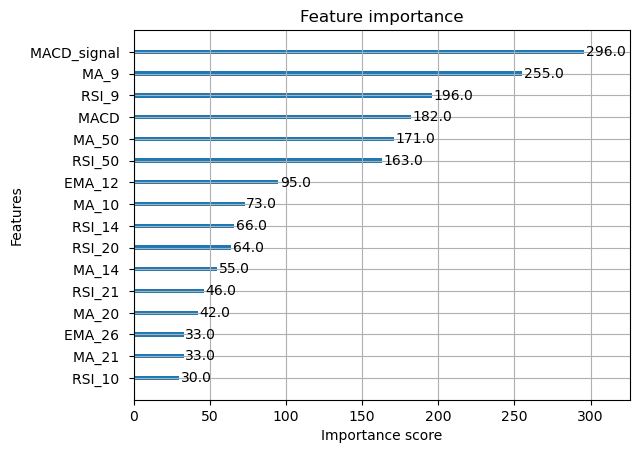

In [42]:
# Plotting each importance variable level
plot_importance(model)

In [43]:
# Predict training data
ytrainpred = model.predict(xtrain)
print(f"ytrain {np.array(ytrain)[:5]}")
print(f"ytrainpred {np.array(ytrainpred)[:5]}")

ytrain [87.39204407 87.34726715 86.90515137 87.3697052  87.9842453 ]
ytrainpred [86.66845  86.66845  86.645645 87.65336  87.615776]


In [44]:
print(f"Mean Squared Error {mean_squared_error(ytrain,ytrainpred)}")

Mean Squared Error 3.1339064657762634


In [45]:
#Predict validation data
yvalidpred = model.predict(xvalid)
print(f"yvalid: {np.array(yvalid)[:5]}")
print(f"yvalidpred: {np.array(yvalidpred)[:5]}")

yvalid: [367.72375488 369.2142334  373.20144653 378.55804443 378.33447266]
yvalidpred: [365.8256  363.80893 364.4037  364.52765 364.68552]


In [46]:
print(f"Mean Squared Error {mean_squared_error(yvalid,yvalidpred)}")

Mean Squared Error 2370.432470580813


in this case, we usually have an overfitting, it's normal because usually we have this error for the type of values

In [47]:
#Predict test data
ytestpred = model.predict(xtest)
print(f"ytest: {np.array(ytest)[:5]}")
print(f"ytestpred: {np.array(ytestpred)[:5]}")

ytest: [406.5246582  407.32098389 404.42971802 405.60525513 400.15463257]
ytestpred: [361.43338 363.18225 363.08093 359.11987 359.67374]


In [48]:
print(f"Mean Squared Error {mean_squared_error(ytest,ytestpred)}")

Mean Squared Error 2233.1311824736763


In [49]:
#Convert predictions into Dataframes
ytrainpred = pd.Series(index=xtrain.index, data=ytrainpred)
yvalidpred = pd.Series(index=xvalid.index, data=yvalidpred)
ytestpred  = pd.Series(index=xtest.index, data=ytestpred)

In [50]:
#Ploting real data vs predictions
fig = make_subplots(rows=1, cols=1)

#Real data
fig.add_trace(go.Scatter(x=ytrain.index, y=ytrain, name="Train dataset", marker_color="blue"), row=1, col=1)
fig.add_trace(go.Scatter(x=yvalid.index, y=yvalid, name="Validation dataset", marker_color="red"), row=1, col=1)
fig.add_trace(go.Scatter(x=ytest.index, y=ytest, name="Test dataset", marker_color="green"), row=1, col=1)

#predicted data
fig.add_trace(go.Scatter(x=ytrainpred.index, y=ytrainpred, name="Predicted Train dataset", marker_color="purple"), row=1, col=1)
fig.add_trace(go.Scatter(x=yvalidpred.index, y=yvalidpred, name="Predicted Validation dataset", marker_color="orange"), row=1, col=1)
fig.add_trace(go.Scatter(x=ytestpred.index, y=ytestpred, name="Predicted Test dataset", marker_color="grey"), row=1, col=1)

fig.update_layout(title="Real vs Predicted data")
fig.show()

## Reminder:
- Some price prediction models tend to be ineffective due to the complexity of the stock market.
- Exhaustive analysis does not necessarily yield better returns.
- There is beauty in simplicity. Often, the simplest elements can prove to be more solid and profitable investment options.